NAME : DHARANISH MS

REGISTER NUMBER: 212223240027

In [1]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
%matplotlib inline

df = pd.read_csv('income (1).csv')

In [2]:
print(len(df))
df.head()

30000


,age,sex,education,education-num,marital-status,workclass,occupation,hours-per-week,income,label
0,27,Male,HS-grad,9,Never-married,Private,Craft-repair,40,<=50K,0
1,47,Male,Masters,14,Married,Local-gov,Exec-managerial,50,>50K,1
2,59,Male,HS-grad,9,Divorced,Self-emp,Prof-specialty,20,<=50K,0
3,38,Female,Prof-school,15,Never-married,Federal-gov,Prof-specialty,57,>50K,1
4,64,Female,11th,7,Widowed,Private,Farming-fishing,40,<=50K,0


In [3]:
df['label'].value_counts()

label
0    21700
1     8300
Name: count, dtype: int64

In [4]:
df.columns

Index(['age', 'sex', 'education', 'education-num', 'marital-status',
       'workclass', 'occupation', 'hours-per-week', 'income', 'label'],
      dtype='str')

In [5]:
# Categorical columns
cat_cols = ['sex', 'education', 'marital-status',
            'workclass', 'occupation']

# Continuous columns
cont_cols = ['age', 'hours-per-week']

# Label column
y_col = ['label']


# RUN THIS CODE TO COMPARE RESULTS:
print(f'cat_cols  has {len(cat_cols)} columns')
print(f'cont_cols has {len(cont_cols)} columns')
print(f'y_col     has {len(y_col)} column')

cat_cols  has 5 columns
cont_cols has 2 columns
y_col     has 1 column


In [6]:
# CODE HERE
for col in cat_cols:
    df[col] = df[col].astype('category')






In [7]:
# THIS CELL IS OPTIONAL
df = shuffle(df, random_state=101)
df.reset_index(drop=True, inplace=True)
df.head()

,age,sex,education,education-num,marital-status,workclass,occupation,hours-per-week,income,label
0,23,Female,HS-grad,9,Never-married,Private,Other-service,50,<=50K,0
1,37,Female,Prof-school,15,Married,State-gov,Prof-specialty,39,>50K,1
2,34,Male,Some-college,10,Divorced,Private,Adm-clerical,40,<=50K,0
3,31,Male,HS-grad,9,Married,Private,Craft-repair,40,>50K,1
4,20,Female,Some-college,10,Never-married,Private,Sales,25,<=50K,0


In [8]:
# Number of categories in each categorical column
cat_szs = [len(df[col].cat.categories) for col in cat_cols]

# Embedding sizes
emb_szs = [(size, min(50, (size + 1) // 2)) for size in cat_szs]

print(cat_szs)
print(emb_szs)

[2, 14, 6, 5, 12]
[(2, 1), (14, 7), (6, 3), (5, 3), (12, 6)]


In [9]:
# Create NumPy array of categorical values

cats = np.stack([df[col].cat.codes.values for col in cat_cols], axis=1)

# View first 5 rows
cats[:5]

array([[ 0, 10,  3,  2,  6],
       [ 0, 12,  1,  4,  7],
       [ 1, 13,  0,  2,  0],
       [ 1, 10,  1,  2,  1],
       [ 0, 13,  3,  2,  9]], dtype=int8)

In [10]:
# Convert cats NumPy array to tensor

cats = torch.tensor(cats, dtype=torch.int64)

# Check datatype
cats.dtype

torch.int64

In [11]:
# Create NumPy array of continuous values

conts = np.stack([df[col].values for col in cont_cols], axis=1)

# Convert to float
conts = conts.astype(np.float32)

# View first 5 rows
conts[:5]

array([[23., 50.],
       [37., 39.],
       [34., 40.],
       [31., 40.],
       [20., 25.]], dtype=float32)

In [12]:
# Convert conts NumPy array to tensor

conts = torch.tensor(conts, dtype=torch.float32)

# Check datatype
conts.dtype

torch.float32

In [13]:
# Create label tensor

y = torch.tensor(df[y_col].values.flatten(), dtype=torch.long)

# Check shape
y.shape

torch.Size([30000])

In [14]:
# Batch size and test size

b = 30000
t = 5000

# Training sets
cat_train = cats[:b-t]
con_train = conts[:b-t]
y_train = y[:b-t]

# Test sets
cat_test = cats[b-t:b]
con_test = conts[b-t:b]
y_test = y[b-t:b]

# Check sizes
print(len(cat_train))
print(len(cat_test))

25000
5000


In [15]:

class TabularModel(nn.Module):

    def __init__(self, emb_szs, n_cont, out_sz, layers, p=0.5):
        super().__init__()

        # Embedding layers
        self.embeds = nn.ModuleList([
            nn.Embedding(ni, nf) for ni, nf in emb_szs
        ])

        self.emb_drop = nn.Dropout(p)

        # Batch normalization for continuous data
        self.bn_cont = nn.BatchNorm1d(n_cont)

        # Fully connected layers
        layerlist = []
        n_emb = sum([nf for ni, nf in emb_szs])
        n_in = n_emb + n_cont

        for i in layers:
            layerlist.append(nn.Linear(n_in, i))
            layerlist.append(nn.ReLU(inplace=True))
            layerlist.append(nn.BatchNorm1d(i))
            layerlist.append(nn.Dropout(p))
            n_in = i

        layerlist.append(nn.Linear(layers[-1], out_sz))

        self.layers = nn.Sequential(*layerlist)

    def forward(self, x_cat, x_cont):

        embeddings = []

        for i, e in enumerate(self.embeds):
            embeddings.append(e(x_cat[:, i]))

        x = torch.cat(embeddings, 1)
        x = self.emb_drop(x)

        x_cont = self.bn_cont(x_cont)

        x = torch.cat([x, x_cont], 1)
        x = self.layers(x)

        return x

In [16]:
# Set random seed

torch.manual_seed(33)

In [17]:
# Create TabularModel instance

model = TabularModel(
    emb_szs,
    conts.shape[1],
    2,
    [50],
    p=0.4
)

model

TabularModel(
  (embeds): ModuleList(
    (0): Embedding(2, 1)
    (1): Embedding(14, 7)
    (2): Embedding(6, 3)
    (3): Embedding(5, 3)
    (4): Embedding(12, 6)
  )
  (emb_drop): Dropout(p=0.4, inplace=False)
  (bn_cont): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layers): Sequential(
    (0): Linear(in_features=22, out_features=50, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=50, out_features=2, bias=True)
  )
)

In [18]:
# Loss function

criterion = nn.CrossEntropyLoss()

# Optimizer

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [19]:
import time

start_time = time.time()

epochs = 300
losses = []

for i in range(epochs):

    # Forward pass
    y_pred = model(cat_train, con_train)

    # Calculate loss
    loss = criterion(y_pred, y_train)

    # Save loss
    losses.append(loss.item())

    # Print every 25 epochs
    if i % 25 == 0:
        print(f'Epoch: {i:3}  Loss: {loss.item():10.8f}')

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(f'\nDuration: {time.time() - start_time:.0f} seconds')

Epoch:   0  Loss: 0.81377232
Epoch:  25  Loss: 0.59307522
Epoch:  50  Loss: 0.51390457
Epoch:  75  Loss: 0.46117699
Epoch: 100  Loss: 0.42819440
Epoch: 125  Loss: 0.39755958
Epoch: 150  Loss: 0.38082534
Epoch: 175  Loss: 0.35858384
Epoch: 200  Loss: 0.34402204
Epoch: 225  Loss: 0.33575210
Epoch: 250  Loss: 0.32717407
Epoch: 275  Loss: 0.32316059

Duration: 22 seconds


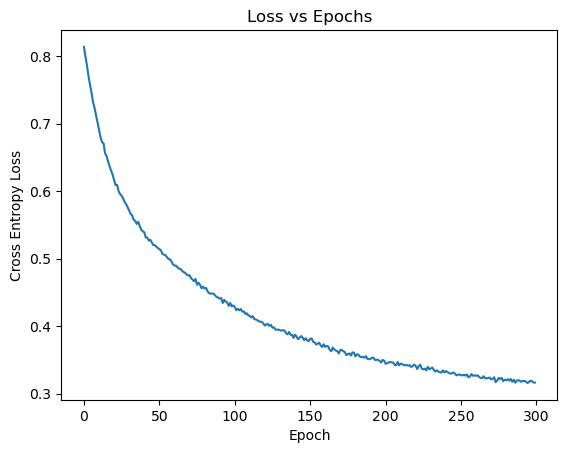

In [20]:


# Plot loss vs epochs

plt.plot(range(epochs), losses)

plt.ylabel('Cross Entropy Loss')
plt.xlabel('Epoch')
plt.title('Loss vs Epochs')

plt.show()

In [21]:
# Evaluate test set

with torch.no_grad():

    y_val = model(cat_test, con_test)

    loss = criterion(y_val, y_test)

print(f'Cross Entropy Loss: {loss:.8f}')

Cross Entropy Loss: 0.33355838


In [22]:
# Calculate overall accuracy

correct = 0

for i in range(len(y_test)):

    if y_val[i].argmax().item() == y_test[i]:
        correct += 1

accuracy = 100 * correct / len(y_test)

print(f'Accuracy: {accuracy:.2f}%')

Accuracy: 84.44%


In [26]:
def predict_income():

    model.eval()

    # Dictionaries
    sex_d = {'Female': 0, 'Male': 1}

    education_d = {
        'Bachelors': 0,
        'Hs-Grad': 1,
        'Masters': 2,
        'Some-College': 3
    }

    marital_d = {
        'Divorced': 0,
        'Married': 1,
        'Never-Married': 2,
        'Separated': 3,
        'Widowed': 4
    }

    workclass_d = {
        'Government': 0,
        'Private': 1,
        'Self-Emp': 2
    }

    occupation_d = {
        'Admin': 0,
        'Exec-Managerial': 1,
        'Sales': 2,
        'Tech-Support': 3
    }

    # User inputs
    age = float(input("Age: "))
    hours = float(input("Hours worked per week: "))

    sex = input("Sex (Female/Male): ").strip().title()
    education = input("Education: ").strip().title()
    marital = input("Marital Status: ").strip().title()
    workclass = input("Workclass: ").strip().title()
    occupation = input("Occupation: ").strip().title()

    # Convert categorical values
    cats = torch.tensor([
        sex_d[sex],
        education_d[education],
        marital_d[marital],
        workclass_d[workclass],
        occupation_d[occupation]
    ], dtype=torch.int64).reshape(1, -1)

    # Continuous values
    conts = torch.tensor([
        age,
        hours
    ], dtype=torch.float32).reshape(1, -1)

    # Prediction
    with torch.no_grad():
        y_val = model(cats, conts)
        prediction = torch.argmax(y_val).item()

    # Output
    if prediction == 1:
        print("Model Prediction: Income >50K")
    else:
        print("Model Prediction: Income <=50K")


# Run the function
predict_income()

Age:  22
Hours worked per week:  40
Sex (Female/Male):  male
Education:  Bachelors
Marital Status:  never-married
Workclass:  private
Occupation:  sales


Model Prediction: Income <=50K
